# Fase 1 — Entendimento dos Dados
---

## Objetivo 

Entendimento dos dados

- O que cada coluna representa?
- Quais variáveis têm dados faltando (nulos)?
- Qual é a distribuição da variável que queremos prever (`inadimplente`)?
- Quais variáveis parecem ter relação com a inadimplência?

---

## Datasets disponíveis

| Arquivo | Descrição |
|---|---|
| `credito_aplicacao_clientes.csv` | Dados cadastrais de 200 clientes novos (Serasa, iFood, Google Maps, etc.) |
| `credito_comportamental_pedidos.csv` | Histórico de 200 pedidos de clientes já ativos |

## 0. Importações

- `pandas`: manipulação e análise de dados tabulares
- `numpy`: operações numéricas
- `matplotlib` e `seaborn`: visualização de dados

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

COR_ADIMPLENTE   = '#2E75B6'
COR_INADIMPLENTE = '#C0392B' 
COR_DESTAQUE     = '#E67E22'

print('Bibliotecas importadas com sucesso')

Bibliotecas importadas com sucesso


---
## 1. Carregamento dos Datasets

In [5]:
# Carregamento dos dois datasets
df_clientes = pd.read_csv('../dados/Brutos/credito_aplicacao_clientes.csv', sep=',')  # Dados externos de clientes Novos
df_pedidos  = pd.read_csv('../dados/Brutos/credito_comportamental_pedidos.csv', sep=',')  # Pedidos de clientes recorrentes

print('Datasets carregados')
print(f'  Clientes: {df_clientes.shape[0]} linhas x {df_clientes.shape[1]} colunas')
print(f'  Pedidos:  {df_pedidos.shape[0]} linhas x {df_pedidos.shape[1]} colunas')

Datasets carregados
  Clientes: 200 linhas x 20 colunas
  Pedidos:  200 linhas x 5 colunas


---
## 2. Exploração Inicial — Tabela de Clientes

### 2.1 Primeiras linhas

In [3]:
df_clientes.head()

,id_cliente,uf,municipio,segmento_cliente,natureza_juridica,fonte_cliente,cnae_codigo,cnae_descricao,capital_social,idade_cnpj,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_credores,serasa_socio_tem_negativacao,ifood_contagem_avaliacoes,ifood_faixa_preco,google_maps_avaliacao,google_maps_contagem_avaliacoes,google_maps_tem_website,inadimplente
0,5649308221613,PE,RECIFE,Restaurante Brasileiro,230-5 - Empresa Individual de Responsabilidade...,Fonte 5,56.11-2-01,Restaurantes e similares,"(100000, 200000]","(8000, 25000]",0.0,0.0,NaN,0.0,"(200, 500]",$$$$$,"(4.0, 4.5]","(1000, 2500]",1.0,0.0
1,5728626180269,PE,RECIFE,Padaria,230-5 - Empresa Individual de Responsabilidade...,Fonte 5,10.91-1-02,Fabricação de produtos de padaria e confeitari...,"(70000, 100000]","(8000, 25000]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
2,5740206260397,PE,JABOATAO DOS GUARARAPES,Conveniência,206-2 - Sociedade Empresária Limitada,Fonte 5,46.13-3-00,Representantes comerciais e agentes do comérci...,"(8000, 10000]","(5000, 8000]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
3,5741028343981,PE,FERNANDO DE NORONHA,Hotel,206-2 - Sociedade Empresária Limitada,Fonte 5,55.10-8-01,Hotéis,"(8000, 10000]","(5000, 8000]",0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
4,5741479985325,PE,RECIFE,Churrascaria,206-2 - Sociedade Empresária Limitada,Fonte 5,56.11-2-01,Restaurantes e similares,"(200000, 1000000]","(8000, 25000]",0.0,0.0,NaN,0.0,"(50, 100]",$,"(4.0, 4.5]","(30, 50]",1.0,0.0


**Observações:**
- `capital_social` e `idade_cnpj` estão como texto no formato de intervalo (ex: `"(100000, 200000]"`), não como números
- `serasa_credores`, `ifood_contagem_avaliacoes` e outras colunas aparecem vazias em alguns clientes (são dados que só existem se o cliente usa aquela plataforma)

### 2.2 Estrutura e Tipos de Dados

OBS.: Algoritmos de ML só aceitam números. Qualquer coluna do tipo texto precisará ser convertida antes da modelagem,. Analisando as informações abaixo das colunas, observamos que a maioria são categóricos (14 colunas de 20 no total), sendo essencial transformar esses dados categóricos em numéricos na fase de pré-processamento de dados.

In [7]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_cliente                       200 non-null    int64  
 1   uf                               200 non-null    object 
 2   municipio                        200 non-null    object 
 3   segmento_cliente                 200 non-null    object 
 4   natureza_juridica                200 non-null    object 
 5   fonte_cliente                    200 non-null    object 
 6   cnae_codigo                      200 non-null    object 
 7   cnae_descricao                   200 non-null    object 
 8   capital_social                   200 non-null    object 
 9   idade_cnpj                       200 non-null    object 
 10  serasa_contagem_negativacoes     200 non-null    float64
 11  serasa_contagem_protestos        200 non-null    float64
 12  serasa_credores       

### 2.3 Estatísticas Descritivas

`df.describe()` calcula automaticamente média, desvio padrão, mínimo, máximo e percentis para colunas numéricas.  
Detectar outliers e verificar se a escala das variáveis faz sentido, observa-se que por existir muitas colunas categóricas nos dados brutos, será necessário a utilização do `df.describe()`mais uma vez para moostrar o cálculo com todas as colunas sendo numéricas.

In [8]:
df_clientes.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_cliente,200.0,NaN,NaN,NaN,5907831773438.919922,80065214129.007324,5649308221613.0,5861011972269.0,5917331521709.0,5982051106989.0,6007116071085.0
uf,200,2,PE,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
municipio,200,18,RECIFE,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segmento_cliente,200,18,Padaria,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
natureza_juridica,200,4,206-2 - Sociedade Empresária Limitada,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fonte_cliente,200,4,Fonte 5,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cnae_codigo,200,31,56.11-2-01,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cnae_descricao,200,31,Restaurantes e similares,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital_social,200,16,"(70000, 100000]",37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
idade_cnpj,200,4,"(5000, 8000]",117,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.4 Valores Nulos

1. **Nulo = dado faltante** (erro, dado não coletado): deve imputar com mediana, moda ou valor especial
2. **Nulo = informação em si** (ex: `ifood_contagem_avaliacoes = NaN`): o nulo não deve ser preenchido, deve virar uma variável binária `tem_ifood = 0`

In [9]:
# total de nulos e percentual em relação ao total de linhas
nulos = pd.DataFrame({
    'total_nulos': df_clientes.isnull().sum(),
    'pct_nulos': (df_clientes.isnull().sum() / len(df_clientes) * 100).round(1)
}).query('total_nulos > 0').sort_values('pct_nulos', ascending=False)

print('Colunas com valores nulos')
print(nulos.to_string())
print(f'\nTotal de colunas sem nenhum nulo: {df_clientes.shape[1] - len(nulos)} de {df_clientes.shape[1]}')

Colunas com valores nulos
                                 total_nulos  pct_nulos
serasa_credores                          171       85.5
ifood_contagem_avaliacoes                151       75.5
ifood_faixa_preco                        138       69.0
google_maps_avaliacao                    118       59.0
google_maps_contagem_avaliacoes          104       52.0
google_maps_tem_website                  104       52.0

Total de colunas sem nenhum nulo: 14 de 20


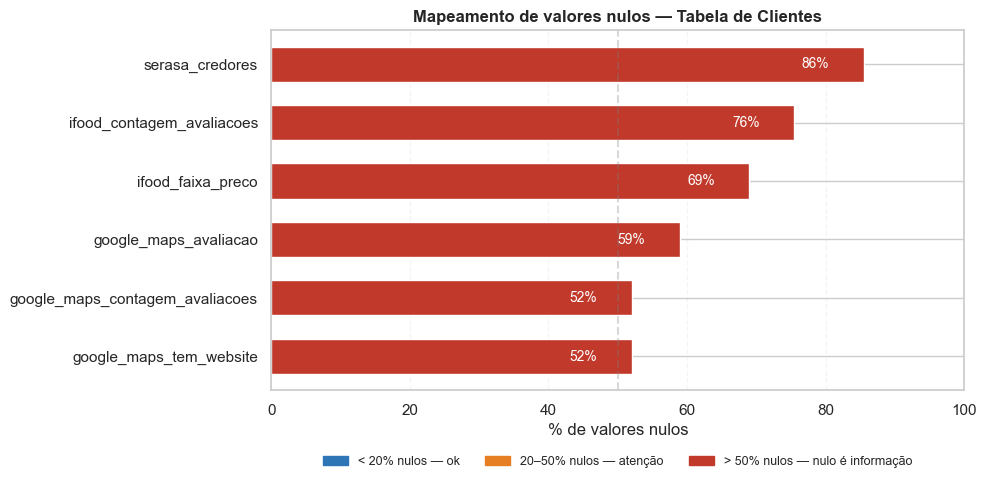

Gráfico salvo em resultados/nulos_clientes.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

cores = [
    COR_INADIMPLENTE if p > 50 else
    COR_DESTAQUE if p > 20 else
    COR_ADIMPLENTE
    for p in nulos['pct_nulos']
]

bars = ax.barh(nulos.index, nulos['pct_nulos'], color=cores, height=0.6)

# 🔹 Ajuste 1: colocar texto DENTRO da barra (ou próximo, se pequena)
for bar, val in zip(bars, nulos['pct_nulos']):
    largura = bar.get_width()
    
    if largura > 10:
        ax.text(largura - 5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', ha='right', color='white', fontsize=10)
    else:
        ax.text(largura + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', ha='left', color='black', fontsize=10)

ax.axvline(50, color='gray', linestyle='--', alpha=0.3)

ax.grid(axis='x', linestyle='--', alpha=0.2)

ax.invert_yaxis()

#  Labels
ax.set_xlabel('% de valores nulos')
ax.set_title('Mapeamento de valores nulos — Tabela de Clientes', fontweight='bold')
ax.set_xlim(0, 100)

from matplotlib.patches import Patch

legenda = [
    Patch(color=COR_ADIMPLENTE,   label='< 20% nulos — ok'),
    Patch(color=COR_DESTAQUE,     label='20–50% nulos — atenção'),
    Patch(color=COR_INADIMPLENTE, label='> 50% nulos — nulo é informação'),
]

ax.legend(handles=legenda,
          loc='upper center',
          bbox_to_anchor=(0.5, -0.15),
          ncol=3,
          frameon=False,
          fontsize=9)

plt.tight_layout()
plt.savefig('../resultados/nulos_clientes.png', dpi=150, bbox_inches='tight')
plt.show()

print('Gráfico salvo em resultados/nulos_clientes.png')

**Interpretação dos nulos:**

| Coluna | % Nulos | Interpretação | Estratégia na Fase 3 |
|---|---|---|---|
| `serasa_credores` | 85.5% | Cliente não deve para ninguém | Criar `tem_credores = 0`, extrair features da lista quando não-nulo |
| `ifood_contagem_avaliacoes` | 75.5% | Cliente não está no iFood | Criar `tem_ifood = 0` |
| `ifood_faixa_preco` | 69.0% | Idem iFood | Tratar junto com `tem_ifood` |
| `google_maps_avaliacao` | 59.0% | Cliente não está no Google Maps | Criar `tem_google_maps = 0` |
| `google_maps_contagem_avaliacoes` | 52.0% | Igual Google Maps | Tratar junto |
| `google_maps_tem_website` | 52.0% | Igual Google Maps | Tratar junto |

**Conclusão:** Nenhuma coluna precisa de imputação tradicional (mediana/moda). Todos os nulos carregam uma informação

---
## 3. Variável Alvo — `inadimplente`

Essa é a variável que queremos prever

**Análise do desbalanceamento**  
Se 95% dos clientes são adimplentes e 5% são inadimplentes, um modelo que sempre prediz adimplente teria 95% de acurácia, mas seria inútil. Por isso usamos ROC-AUC como métrica, que é eficaz ao desbalanceamento.

In [11]:
n_total        = len(df_clientes)
n_inadimplente = int(df_clientes['inadimplente'].sum())
n_adimplente   = n_total - n_inadimplente
taxa           = n_inadimplente / n_total

print('Distribuição da Variável Alvo')
print(f'Total de clientes:          {n_total}')
print(f'Adimplentes:                {n_adimplente} ({n_adimplente/n_total*100:.1f}%)')
print(f'Inadimplentes:              {n_inadimplente} ({taxa*100:.1f}%)')
print(f'Razão de desbalanceamento:  {n_adimplente/n_inadimplente:.0f}:1 (adimplentes por inadimplente)')

Distribuição da Variável Alvo
Total de clientes:          200
Adimplentes:                187 (93.5%)
Inadimplentes:              13 (6.5%)
Razão de desbalanceamento:  14:1 (adimplentes por inadimplente)


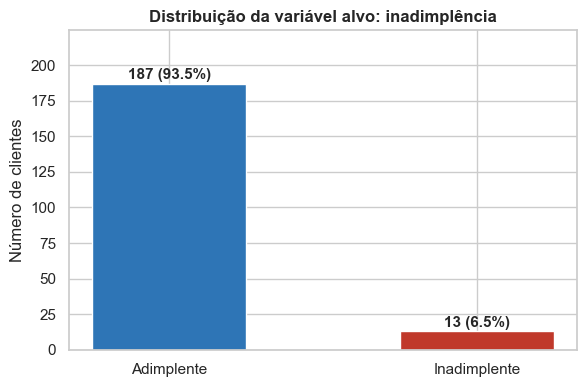

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Adimplente', 'Inadimplente']
valores = [n_adimplente, n_inadimplente]
cores = [COR_ADIMPLENTE, COR_INADIMPLENTE]

bars = ax.bar(labels, valores, color=cores, width=0.5)

total = sum(valores)

#  Mostrar valor + porcentagem
for bar, val in zip(bars, valores):
    pct = (val / total) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f'{val} ({pct:.1f}%)',
            ha='center',
            fontsize=11,
            fontweight='bold')

ax.set_ylabel('Número de clientes')
ax.set_title('Distribuição da variável alvo: inadimplência', fontweight='bold')
ax.set_ylim(0, max(valores) * 1.2)

plt.tight_layout()
plt.savefig('../resultados/variavel_alvo.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretação:**

- Temos apenas 13 inadimplentes em 200 clientes (6.5%) — desbalanceamento de ~14:1
- Isso significa que na Fase 4 (modelagem) vamos usar:
  - `class_weight='balanced'` para compensar o desbalanceamento
  - `StratifiedKFold` no cross-validation (garante que cada fold tem a mesma proporção de inadimplentes)
  - ROC-AUC como métrica principal (não acurácia)
- Com apenas 13 inadimplentes, o modelo terá alta variância nas estimativas, diferenças de AUC menores que 0.02 entre modelos não são estatisticamente significativas

---
## 4. Análise de Variáveis Categóricas vs Inadimplência

Para cada variável categórica, calculamos a taxa de inadimplência por grupo    
Grupos com taxa muito acima da média (6.5%) são potencialmente preditivos  

**Grupos pequenos:** um grupo com 2 clientes onde 1 é inadimplente tem taxa de 50%, mas isso pode ser acaso. Grupos com menos de 5 clientes serão instáveis.

In [17]:
def taxa_inadimplencia_por_grupo(df, coluna, min_clientes=5):
    """
    Calcula a taxa de inadimplência por categoria de uma coluna.
    Retorna DataFrame ordenado pela taxa, com flag de grupos pequenos.
    Parâmetro min_clientes: grupos com menos que isso são sinalizados como estatisticamente instáveis.
    """
    resultado = (
        df.groupby(coluna)['inadimplente']
        .agg(n_clientes='count', n_inadimplentes='sum')
        .assign(taxa=lambda x: x['n_inadimplentes'] / x['n_clientes'])
        .sort_values('taxa', ascending=False)
        .reset_index()
    )
    resultado['instavel'] = resultado['n_clientes'] < min_clientes
    return resultado

### 4.1 Unidade Federativa (UF)

In [20]:
uf_stats = taxa_inadimplencia_por_grupo(df_clientes, 'uf')
print(uf_stats.to_string(index=False))
print('\nObservação: taxas muito próximas (PE 6.5% vs CE 6.2%) — UF provavelmente tem baixo poder preditivo')

uf  n_clientes  n_inadimplentes     taxa  instavel
PE         168             11.0 0.065476     False
CE          32              2.0 0.062500     False

Observação: taxas muito próximas (PE 6.5% vs CE 6.2%) — UF provavelmente tem baixo poder preditivo


### 4.2 Segmento do Cliente

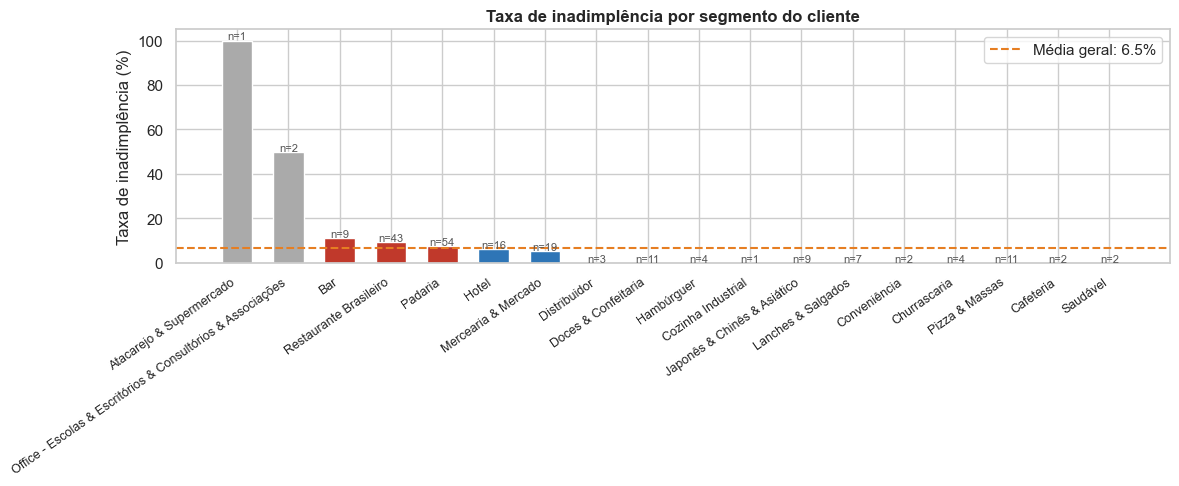


Grupos estáveis (n >= 5) com maior inadimplência
      segmento_cliente  n_clientes     taxa
                   Bar           9 0.111111
Restaurante Brasileiro          43 0.093023
               Padaria          54 0.074074
                 Hotel          16 0.062500
   Mercearia & Mercado          19 0.052632


In [24]:
seg_stats = taxa_inadimplencia_por_grupo(df_clientes, 'segmento_cliente')

fig, ax = plt.subplots(figsize=(12, 5))

# vermelho se acima da média, azul se abaixo, cinza se instável
cores = []
for _, row in seg_stats.iterrows():
    if row['instavel']:
        cores.append('#AAAAAA')
    elif row['taxa'] > taxa:
        cores.append(COR_INADIMPLENTE)
    else:
        cores.append(COR_ADIMPLENTE)

bars = ax.bar(seg_stats['segmento_cliente'], seg_stats['taxa'] * 100,
              color=cores, width=0.6)

# Linha da média geral
ax.axhline(taxa * 100, color=COR_DESTAQUE, linestyle='--', linewidth=1.5,
           label=f'Média geral: {taxa*100:.1f}%')

# Anotações com n_clientes
for bar, (_, row) in zip(bars, seg_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'n={int(row["n_clientes"])}', ha='center', fontsize=8, color='#555')

ax.set_ylabel('Taxa de inadimplência (%)')
ax.set_title('Taxa de inadimplência por segmento do cliente', fontweight='bold')
ax.legend()
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('../resultados/inadimplencia_por_segmento.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGrupos estáveis (n >= 5) com maior inadimplência')
print(seg_stats[~seg_stats['instavel']].head(5)[['segmento_cliente','n_clientes','taxa']].to_string(index=False))

### 4.3 Fonte de Aquisição do Cliente

In [25]:
fonte_stats = taxa_inadimplencia_por_grupo(df_clientes, 'fonte_cliente')
print(fonte_stats.to_string(index=False))
print('\nNota: Fonte 5 domina a base (181/200 clientes). As outras fontes têm amostras muito pequenas.')

fonte_cliente  n_clientes  n_inadimplentes     taxa  instavel
      Fonte 1          10              1.0 0.100000     False
      Fonte 5         181             12.0 0.066298     False
      Fonte 2           4              0.0 0.000000      True
      Fonte 4           5              0.0 0.000000     False

Nota: Fonte 5 domina a base (181/200 clientes). As outras fontes têm amostras muito pequenas.


### 4.4 Natureza Jurídica

In [26]:
nj_stats = taxa_inadimplencia_por_grupo(df_clientes, 'natureza_juridica')

nj_stats['natureza_curta'] = nj_stats['natureza_juridica'].str.extract(r'- (.+)$')[0]

print(nj_stats[['natureza_curta','n_clientes','n_inadimplentes','taxa']].to_string(index=False))

                                                          natureza_curta  n_clientes  n_inadimplentes     taxa
                                                 Empresário (Individual)          43              4.0 0.093023
                                           Sociedade Empresária Limitada         126              8.0 0.063492
Empresa Individual de Responsabilidade Limitada (de Natureza Empresária)          30              1.0 0.033333
                                               Sociedade Anônima Fechada           1              0.0 0.000000


### 4.5 Presença no iFood e Google Maps

Verificamos se estar ou não estar nessas plataformas diferencia a inadimplência.

In [20]:
df_clientes['tem_ifood']       = df_clientes['ifood_contagem_avaliacoes'].notna().astype(int)
df_clientes['tem_google_maps'] = df_clientes['google_maps_avaliacao'].notna().astype(int)

print('Presença digital vs inadimplência')
for col, nome in [('tem_ifood', 'iFood'), ('tem_google_maps', 'Google Maps')]:
    stats = taxa_inadimplencia_por_grupo(df_clientes, col)
    stats[col] = stats[col].map({0: f'Sem {nome}', 1: f'Com {nome}'})
    print(f'\n{nome}:')
    print(stats[[col, 'n_clientes', 'taxa']].to_string(index=False))

Presença digital vs inadimplência

iFood:
tem_ifood  n_clientes     taxa
Sem iFood         151 0.072848
Com iFood          49 0.040816

Google Maps:
tem_google_maps  n_clientes    taxa
Sem Google Maps         118 0.09322
Com Google Maps          82 0.02439


---
## 5. Análise de Variáveis Numéricas vs Inadimplência

### 5.1 Serasa — Negativações e Protestos

**Hipótese:** clientes com mais negativações/protestos deveriam ter maior risco de inadimplência

In [29]:
print('Negativações no Serasa')
print(df_clientes['serasa_contagem_negativacoes'].describe())
print(f"\nClientes SEM negativação:    {(df_clientes['serasa_contagem_negativacoes']==0).sum()} clientes")
print(f"Clientes COM negativação:    {(df_clientes['serasa_contagem_negativacoes']>0).sum()} clientes")
print()

# Taxa de inadimplência por grupo (0 negativações vs 1+ negativações)
df_clientes['tem_negativacao'] = (df_clientes['serasa_contagem_negativacoes'] > 0).astype(int)
neg_stats = taxa_inadimplencia_por_grupo(df_clientes, 'tem_negativacao')
neg_stats['tem_negativacao'] = neg_stats['tem_negativacao'].map({0: 'Sem negativação', 1: 'Com negativação'})
print(neg_stats[['tem_negativacao','n_clientes','taxa']].to_string(index=False))
print()
print('Nota: Clientes sem negativação têm taxa maior (7.4%) que com negativação (3.8%).')
print('Possível explicação: clientes com muitas negativações já foram filtrados antes de entrar na base.')

Negativações no Serasa
count    200.00000
mean       1.95500
std        9.82014
min        0.00000
25%        0.00000
50%        0.00000
75%        1.00000
max      126.00000
Name: serasa_contagem_negativacoes, dtype: float64

Clientes SEM negativação:    148 clientes
Clientes COM negativação:    52 clientes

tem_negativacao  n_clientes     taxa
Sem negativação         148 0.074324
Com negativação          52 0.038462

Nota: Clientes sem negativação têm taxa maior (7.4%) que com negativação (3.8%).
Possível explicação: clientes com muitas negativações já foram filtrados antes de entrar na base.


In [30]:
# Sócio com negativação vs sem
socio_stats = taxa_inadimplencia_por_grupo(df_clientes, 'serasa_socio_tem_negativacao')
socio_stats['serasa_socio_tem_negativacao'] = socio_stats['serasa_socio_tem_negativacao'].map(
    {0.0: 'Sócio sem negativação', 1.0: 'Sócio COM negativação'}
)
print('Sócio tem negativação')
print(socio_stats[['serasa_socio_tem_negativacao','n_clientes','taxa']].to_string(index=False))
print('\nSócios com negativação têm taxa 63% maior que sem (8.7% vs 5.3%)')

Sócio tem negativação
serasa_socio_tem_negativacao  n_clientes     taxa
       Sócio COM negativação          69 0.086957
       Sócio sem negativação         131 0.053435

Sócios com negativação têm taxa 63% maior que sem (8.7% vs 5.3%)


### 5.2 Variáveis de Intervalo — Idade do CNPJ

`idade_cnpj` está no formato `"(5000, 8000]"`: precisa ser tratada para análise.  
Criação de versão temporária só para visualização (o tratamento definitivo fica na Fase 3).

In [32]:
# Verificar os intervalos únicos presentes
print('Intervalos únicos de idade_cnpj:')
print(df_clientes['idade_cnpj'].value_counts().sort_index())
print()
print('Análise: apenas 4 faixas distintas. O dataset atual tem poucos clientes novos.')
print('A maioria tem CNPJ com mais de 5000 dias (13+ anos) — base de clientes madura.')

Intervalos únicos de idade_cnpj:
idade_cnpj
(4000, 5000]       4
(5000, 8000]     117
(8000, 25000]     77
(900, 1150]        2
Name: count, dtype: int64

Análise: apenas 4 faixas distintas. O dataset atual tem poucos clientes novos.
A maioria tem CNPJ com mais de 5000 dias (13+ anos) — base de clientes madura.


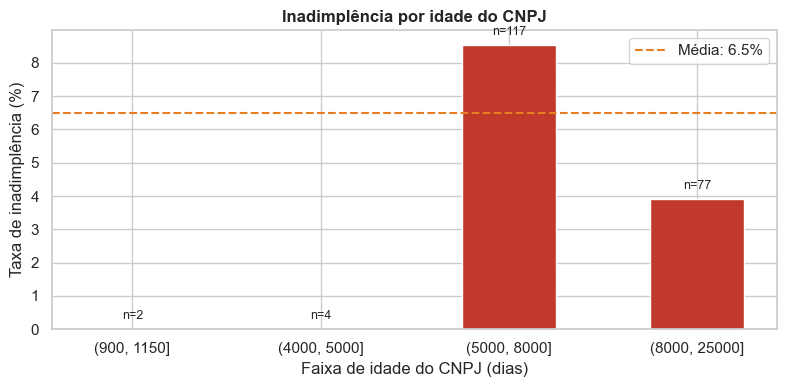

In [38]:
idade_stats = taxa_inadimplencia_por_grupo(df_clientes, 'idade_cnpj')

# Ordenar por mínimo do intervalo
def extrair_min_intervalo(s):
    try:
        return float(s.strip('([])').split(',')[0])
    except:
        return 0

idade_stats['min_val'] = idade_stats['idade_cnpj'].apply(extrair_min_intervalo)
idade_stats = idade_stats.sort_values('min_val')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(idade_stats['idade_cnpj'], idade_stats['taxa'] * 100,
              color=COR_INADIMPLENTE, width=0.5)
ax.axhline(taxa * 100, color=COR_DESTAQUE, linestyle='--',
           label=f'Média: {taxa*100:.1f}%')

for bar, (_, row) in zip(bars, idade_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'n={int(row["n_clientes"])}', ha='center', fontsize=9)

ax.set_xlabel('Faixa de idade do CNPJ (dias)')
ax.set_ylabel('Taxa de inadimplência (%)')
ax.set_title('Inadimplência por idade do CNPJ', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../resultados/inadimplencia_por_idade_cnpj.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Exploração Inicial — Tabela de Pedidos

### 6.1 Estrutura e Primeiras Linhas

In [42]:
print('Primeiras linhas')
display(df_pedidos.head(10))
print()
print('Tipos de dados e nulos')
df_pedidos.info()

Primeiras linhas


,id_pedido,id_cliente,valor,atraso,data_entrega
0,6257585946797,5594576584877,239.06,0.0,2025-08-04
1,6258000789677,5594576584877,273.12,0.0,2025-08-04
2,6262535717037,5594576584877,253.45,0.0,2025-08-07
3,6262547972269,5594576584877,246.76,7.0,2025-08-07
4,6264005820589,5594576584877,147.96,3.0,2025-08-08
5,6268097921197,5594576584877,399.70,0.0,2025-08-11
6,6268274901165,5594576584877,67.78,0.0,2025-08-11
7,6271370166445,5594576584877,179.70,0.0,2025-08-13
8,6274197258413,5594576584877,252.74,2.0,2025-08-15
9,6280429371565,5594576584877,843.14,0.0,2025-08-19



Tipos de dados e nulos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_pedido     200 non-null    int64  
 1   id_cliente    200 non-null    int64  
 2   valor         200 non-null    float64
 3   atraso        200 non-null    float64
 4   data_entrega  200 non-null    object 
dtypes: float64(2), int64(2), object(1)
memory usage: 7.9+ KB


In [43]:
print('Estatísticas descritivas')
display(df_pedidos.describe())

Estatísticas descritivas


,id_pedido,id_cliente,valor,atraso
count,2.000000e+02,2.000000e+02,200.000000,200.000000
mean,6.325109e+12,5.698107e+12,571.109550,0.790000
std,4.383444e+10,5.547990e+10,622.639385,2.644022
min,6.255298e+12,5.594577e+12,21.900000,-6.000000
25%,6.283711e+12,5.649308e+12,186.477500,0.000000
50%,6.324206e+12,5.726056e+12,370.455000,0.000000
75%,6.362210e+12,5.740163e+12,658.590000,2.000000
max,6.395908e+12,5.740213e+12,3465.500000,17.000000


### 6.2 Sobreposição entre as tabelas

In [44]:
clientes_set = set(df_clientes['id_cliente'])
pedidos_set  = set(df_pedidos['id_cliente'])

com_pedido    = clientes_set & pedidos_set
sem_pedido    = clientes_set - pedidos_set
pedidos_orfas = pedidos_set - clientes_set  # pedidos sem cliente correspondente

print('Sobreposição entre tabelas')
print(f'Clientes totais:                {len(clientes_set)}')
print(f'Clientes únicos nos pedidos:    {len(pedidos_set)}')
print(f'Clientes COM pedido:            {len(com_pedido)} ({len(com_pedido)/len(clientes_set)*100:.1f}% dos clientes)')
print(f'Clientes SEM pedido:            {len(sem_pedido)} ({len(sem_pedido)/len(clientes_set)*100:.1f}% dos clientes)')
print(f'Pedidos sem cliente na base:    {len(pedidos_orfas)}')
print()
print('Notas:')
print('Apenas 3 clientes (1.5%) têm dados na tabela de pedidos.')
print('O modelo comportamental só pode avaliar esses 3 clientes.')
print('Os demais 197 só podem ser avaliados pelo modelo de aplicação.')

Sobreposição entre tabelas
Clientes totais:                200
Clientes únicos nos pedidos:    20
Clientes COM pedido:            3 (1.5% dos clientes)
Clientes SEM pedido:            197 (98.5% dos clientes)
Pedidos sem cliente na base:    17

Notas:
Apenas 3 clientes (1.5%) têm dados na tabela de pedidos.
O modelo comportamental só pode avaliar esses 3 clientes.
Os demais 197 só podem ser avaliados pelo modelo de aplicação.


In [45]:
# Detalhes dos clientes que aparecem nos pedidos
clientes_com_historico = df_clientes[df_clientes['id_cliente'].isin(com_pedido)][[
    'id_cliente', 'segmento_cliente', 'municipio', 'inadimplente'
]]
print('Clientes que aparecem na tabela de pedidos')
print(clientes_com_historico.to_string(index=False))
print()
print('Todos os 3 clientes com histórico são ADIMPLENTES.')
print('Isso significa que a tabela de pedidos, nessa amostra, NÃO tem inadimplentes com histórico.')
print('O modelo comportamental terá limitações nesse dataset.')

Clientes que aparecem na tabela de pedidos
   id_cliente       segmento_cliente               municipio  inadimplente
5649308221613 Restaurante Brasileiro                  RECIFE           0.0
5728626180269                Padaria                  RECIFE           0.0
5740206260397           Conveniência JABOATAO DOS GUARARAPES           0.0

Todos os 3 clientes com histórico são ADIMPLENTES.
Isso significa que a tabela de pedidos, nessa amostra, NÃO tem inadimplentes com histórico.
O modelo comportamental terá limitações nesse dataset.


### 6.3 Distribuição de Atraso e Valor dos Pedidos

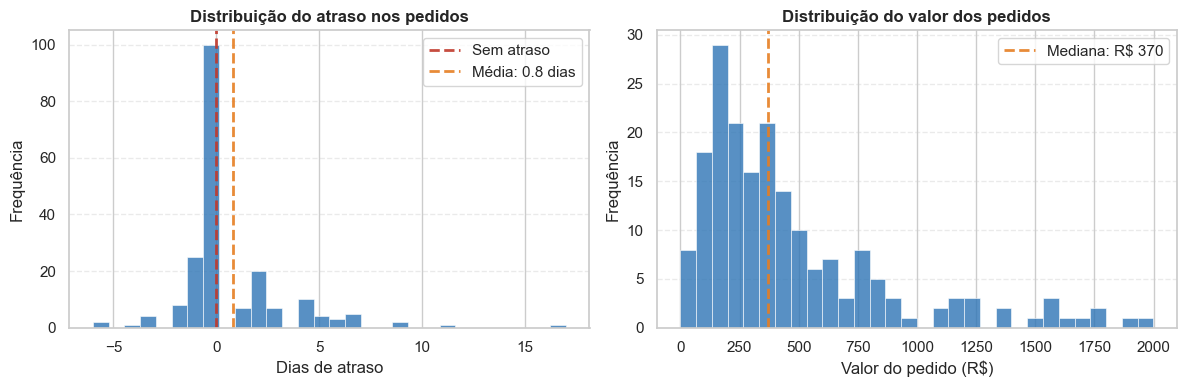

Pedidos com atraso negativo (antecipados): 40
Pedidos sem atraso (= 0):                  100
Pedidos com atraso positivo:               60
Maior atraso registrado:                   17 dias


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de atraso
axes[0].hist(df_pedidos['atraso'],
             bins=30,  # mais detalhe
             color=COR_ADIMPLENTE,
             edgecolor='white',
             linewidth=0.5,
             alpha=0.8)

axes[0].axvline(0,
                color=COR_INADIMPLENTE,
                linestyle='--',
                linewidth=2,
                alpha=0.9,
                label='Sem atraso')

axes[0].axvline(df_pedidos['atraso'].mean(),
                color=COR_DESTAQUE,
                linestyle='--',
                linewidth=2,
                alpha=0.9,
                label=f'Média: {df_pedidos["atraso"].mean():.1f} dias')

axes[0].set_xlabel('Dias de atraso')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do atraso nos pedidos', fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].legend()

# Histograma de valor
# limitar eixo para reduzir efeito de outliers (percentil 95)
limite = df_pedidos['valor'].quantile(0.95)

axes[1].hist(df_pedidos['valor'],
             bins=30,
             range=(0, limite),
             color=COR_ADIMPLENTE,
             edgecolor='white',
             linewidth=0.5,
             alpha=0.8)

axes[1].axvline(df_pedidos['valor'].median(),
                color=COR_DESTAQUE,
                linestyle='--',
                linewidth=2,
                alpha=0.9,
                label=f'Mediana: R$ {df_pedidos["valor"].median():.0f}')

axes[1].set_xlabel('Valor do pedido (R$)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição do valor dos pedidos', fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.savefig('../resultados/distribuicao_pedidos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pedidos com atraso negativo (antecipados): {(df_pedidos["atraso"] < 0).sum()}')
print(f'Pedidos sem atraso (= 0):                  {(df_pedidos["atraso"] == 0).sum()}')
print(f'Pedidos com atraso positivo:               {(df_pedidos["atraso"] > 0).sum()}')
print(f'Maior atraso registrado:                   {df_pedidos["atraso"].max():.0f} dias')

---
## 7. Resumo e Próximos Passos

# RESUMO DA FASE 1 - ENTENDIMENTO DOS DADOS

## TABELA DE CLIENTES (200 linhas x 20 colunas)
- **Taxa de inadimplência:** 6.5% (13 inadimplentes)  
- **Desbalanceamento:** 14.4:1 (adimplentes por inadimplente)  
- **Nulos:** 6 colunas com nulos — todos são informação (não erro)  
- **Tipos:** 11 colunas texto, 5 numéricas, 4 intervalos-texto  

---

## VARIÁVEIS MAIS PROMISSORAS
1. **serasa_socio_tem_negativacao**  
   → sócios negativados: 8.7% vs 5.3%  

2. **segmento_cliente**  
   → Bar (11%), Rest. Brasileiro (9%) acima da média  

3. **tem_google_maps**  
   → presença digital como proxy de formalidade  

4. **natureza_juridica**  
   → estrutura jurídica indica formalização  

---

## VARIÁVEIS COM COMPORTAMENTO CONTRA-INTUITIVO
- **serasa_contagem_negativacoes**  
  → clientes com negativações têm **MENOR taxa?!**  

**Hipótese:**  
Viés de seleção — clientes muito negativados não chegam a se cadastrar  

---

## TABELA DE PEDIDOS (200 linhas x 5 colunas)
- Apenas **3 clientes (1.5%)** da base de clientes aparecem nos pedidos  
- Nenhum desses 3 é inadimplente  

**IMPACTO:**  
Modelo comportamental terá limitações nesta amostra  

---

## DECISÕES PARA A FASE 3 (Feature Engineering)
1. Criar `tem_ifood`, `tem_google_maps`, `tem_credores` (a partir de nulos)  
2. Parsear intervalos: `capital_social`, `idade_cnpj` → ponto médio numérico  
3. Extrair divisão CNAE (primeiros 2 dígitos de `cnae_codigo`)  
4. Processar `serasa_credores`: `n_credores`, diversidade de segmentos  
5. Encoding: one-hot para `fonte_cliente`/`uf`, target encoding para `segmento`  

---

## DECISÕES PARA A FASE 4 (Modelagem)
1. Split estratificado **70/15/15** (treino/validação/teste)  
2. `class_weight='balanced'` para compensar desbalanceamento  
3. **StratifiedKFold (k=5)** no cross-validation  
4. Métrica principal: **ROC-AUC** (não acurácia)  
5. Conjunto de teste **bloqueado** até avaliação final  

In [48]:
# Salvar datasets limpos com a coluna temporária que criamos
# (tem_ifood e tem_google_maps já calculadas — serão recalculadas na Fase 3)
df_clientes_original = df_clientes.drop(columns=['tem_ifood', 'tem_google_maps',
                                                   'tem_negativacao'], errors='ignore')

print('Integridade dos dados originais:')
print(f'  df_clientes: {df_clientes_original.shape} — ok')
print(f'  df_pedidos:  {df_pedidos.shape} — ok')
print()
print('Gráficos salvos em resultados/:')
import os
for f in sorted(os.listdir('../resultados')):
    if f.endswith('.png'):
        print(f'  {f}')

Integridade dos dados originais:
  df_clientes: (200, 20) — ok
  df_pedidos:  (200, 5) — ok

Gráficos salvos em resultados/:
  distribuicao_pedidos.png
  inadimplencia_por_idade_cnpj.png
  inadimplencia_por_segmento.png
  nulos_clientes.png
  variavel_alvo.png
